# Post-confirmation robustness analysis

This is a **post-confirmation robustness analysis**, not model selection. The locked 5-session headline results and failed M6 confirmation remain unchanged. Only the pre-specified static M2 mean-reversion checks are run; no 2025 outcome is used in coefficient estimation or parameter choice. See `docs/forecasts.md`. The 2025 sample is a locked temporal confirmation sample, though earlier full-sample descriptive EDA included it.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.forecasting import DEV_END
from src.time_series import load_skew_metrics
from src.forecast_robustness import (
    SPECIFICATIONS, fit_static_m2, forecast_static_m2,
    build_robustness_outcomes, headline_30d_predictor_dates,
    score_static_m2, nonoverlapping_offsets, extreme_move_check,
    confirmation_top_one_percent_check,
    vix_regime_check, hac_loss_difference, cumulative_m2_gain,
)

metrics = load_skew_metrics(project_root / 'data/processed/spx_skew_metrics_2023_2025.csv')
spx_prices = pd.read_csv(project_root / 'data/raw/spx_security_prices.csv')
vix_prices = pd.read_csv(project_root / 'data/raw/VIX_security_prices.csv')
from src.forecasting import build_locked_feature_panel
panel = build_locked_feature_panel(metrics, spx_prices, vix_prices)
display(pd.Series({'SPX sessions': len(panel), 'development sessions': panel.quote_date.le(DEV_END).sum(), '2025 sessions': panel.quote_date.gt(DEV_END).sum()}))

SPX sessions            667
development sessions    502
2025 sessions           165
dtype: int64

## Static M2 fits and 2025 predictions

Each state uses the frozen expanding z-score with 60 prior valid observations. For each horizon, only development-origin labels that mature by 2024-12-31 enter OLS. Predict 2025 with the single frozen intercept and slope. Outcomes are constructed **after** predictions; no 2025 label is supplied to the fit or forecast functions.

In [2]:
fitted = {spec: fit_static_m2(panel, spx_prices, *spec) for spec in SPECIFICATIONS}
predictions = {spec: forecast_static_m2(fitted[spec], panel, spx_prices) for spec in SPECIFICATIONS}
display(pd.DataFrame([{'state': state, 'horizon': h, 'intercept': fitted[state, h]['intercept'], 'slope': fitted[state, h]['slope'], 'n_development_fit': fitted[state, h]['n_train'], 'last_matured_origin': fitted[state, h]['last_matured_origin']} for state, h in SPECIFICATIONS]))
outcomes = build_robustness_outcomes(panel, spx_prices)

,state,horizon,intercept,slope,n_development_fit,last_matured_origin
0,skew_30,1,0.002084,-0.011570,439,2024-12-30
1,skew_30,5,0.007266,-0.040897,435,2024-12-23
2,skew_30,10,0.010406,-0.053571,430,2024-12-16
3,skew_30_60,1,0.001826,-0.010287,433,2024-12-30
4,skew_30_60,5,0.004940,-0.027615,429,2024-12-23
5,skew_30_60,10,0.006358,-0.033970,424,2024-12-16
6,rr25_30_60,5,0.000654,-0.001725,426,2024-12-23


## Horizon robustness and frozen 5D checkpoint

The 30D 5D headline checkpoint used 158 dates common to M0/M2/M6. Here we reproduce that date set using only availability of the frozen M5b predictor columns—without fitting or predicting M6. Other horizon rows use their own M0/M2 common dates; their loss magnitudes are not directly scale-neutral across horizons. No horizon is selected from this table.

In [3]:
headline_dates_30 = headline_30d_predictor_dates(panel, spx_prices)
scores, common_rows = {}, {}
for spec in SPECIFICATIONS:
    pred = predictions[spec]
    if spec == ('skew_30', 5):
        pred = pred.loc[pred.quote_date.isin(headline_dates_30)]
    scores[spec], common_rows[spec] = score_static_m2(pred, outcomes, fitted[spec]['target'])
horizon_table = pd.DataFrame([{'state': state, 'horizon': h, **scores[state, h]} for state, h in SPECIFICATIONS if state != 'rr25_30_60'])
display(horizon_table.round(6))
assert scores['skew_30', 5]['n'] == 158
assert scores['skew_30_60', 5]['n'] == 158
for spec, rmse_m0, rmse_m2, r2 in [(('skew_30', 5), .1012, .0922, .1695), (('skew_30_60', 5), .0544, .0492, .1824)]:
    row = scores[spec]
    assert abs(row['rmse_m0'] - rmse_m0) < .00005
    assert abs(row['rmse_m2'] - rmse_m2) < .00005
    assert abs(row['r2_vs_m0'] - r2) < .00005
print('Frozen 5D M0/M2 confirmation checkpoints reproduced to reported precision.')

,state,horizon,n,rmse_m0,rmse_m2,mae_m0,mae_m2,r2_vs_m0,correlation,directional_accuracy
0,skew_30,1,164,0.048746,0.047841,0.035875,0.035792,0.036782,0.271750,0.554878
1,skew_30,5,158,0.101203,0.092231,0.073665,0.065720,0.169460,0.576610,0.601266
2,skew_30,10,155,0.135532,0.114370,0.097133,0.084550,0.287908,0.767381,0.516129
3,skew_30_60,1,162,0.037737,0.035672,0.028140,0.028211,0.106434,0.407848,0.530864
4,skew_30_60,5,158,0.054429,0.049215,0.042118,0.036791,0.182415,0.561904,0.620253
5,skew_30_60,10,153,0.072152,0.059618,0.055108,0.044325,0.317248,0.737331,0.620915


Frozen 5D M0/M2 confirmation checkpoints reproduced to reported precision.


## RR25 alternative

The existing QC-masked downside RR25 spread is `rr25_30 - rr25_60`; its sign convention is unchanged. The 5D target is the endpoint change in this spread, with a development-fitted static M2.

In [4]:
display(pd.DataFrame([{'state': 'rr25_30_60', 'horizon': 5, **scores['rr25_30_60', 5]}]).round(6))

,state,horizon,n,rmse_m0,rmse_m2,mae_m0,mae_m2,r2_vs_m0,correlation,directional_accuracy
0,rr25_30_60,5,155,0.005762,0.005074,0.003285,0.002695,0.224621,0.47934,0.612903


## Headline 5D checks

All checks below reuse the 158 scored dates and their unchanged M0/M2 predictions. Offsets use the original SPX session index. The **development-fixed extreme-move threshold** is the 99th percentile of absolute development fitting outcomes, so it need not remove 1% of confirmation observations. Separately, the **confirmation top-1%-removed diagnostic** removes exactly $k=\max(1,\lceil0.01n\rceil)=2$ largest absolute realised 2025 target moves, breaking ties by earliest quote date. This second check uses confirmation outcomes and is explicitly post-confirmation robustness analysis, not an untouched test. Regimes are descriptive splits at the pre-declared VIX level 20, with no model refit.

In [5]:
offset_table = pd.concat([nonoverlapping_offsets(common_rows[spec]).assign(state=spec[0]) for spec in [('skew_30', 5), ('skew_30_60', 5)]], ignore_index=True)
display(offset_table[['state', 'offset', 'n', 'rmse_m0', 'rmse_m2', 'r2_vs_m0']].round(6))
extreme_table = pd.DataFrame([{'state': spec[0], **extreme_move_check(common_rows[spec], fitted[spec]['extreme_cutoff'])} for spec in [('skew_30', 5), ('skew_30_60', 5)]])
print('Development-fixed extreme-move threshold')
display(extreme_table[['state', 'development_cutoff', 'removed', 'n', 'rmse_m0', 'rmse_m2', 'mae_m0', 'mae_m2', 'r2_vs_m0']].round(6))
top_one_percent_table = pd.DataFrame([{'state': spec[0], **confirmation_top_one_percent_check(common_rows[spec])} for spec in [('skew_30', 5), ('skew_30_60', 5)]])
assert top_one_percent_table['removed'].eq(2).all()
print('Confirmation top-1%-removed diagnostic (post-confirmation)')
display(top_one_percent_table[['state', 'removed', 'n', 'rmse_m0', 'rmse_m2', 'mae_m0', 'mae_m2', 'r2_vs_m0']].round(6))
regime_table = pd.concat([vix_regime_check(common_rows[spec], panel).assign(state=spec[0]) for spec in [('skew_30', 5), ('skew_30_60', 5)]], ignore_index=True)
display(regime_table[['state', 'regime', 'n', 'small_sample', 'rmse_m0', 'rmse_m2', 'r2_vs_m0']].round(6))
for spec in [('skew_30', 5), ('skew_30_60', 5)]:
    missing_vix = common_rows[spec]['quote_date'].map(panel.set_index('quote_date')['vix_close']).isna().sum()
    print(f'{spec[0]}: {missing_vix} scored dates have missing VIX and are outside the regime split')

,state,offset,n,rmse_m0,rmse_m2,r2_vs_m0
0,skew_30,0,30,0.098975,0.090138,0.170598
1,skew_30,1,32,0.098082,0.090011,0.157802
2,skew_30,2,32,0.105474,0.095712,0.176551
3,skew_30,3,32,0.093251,0.086308,0.143371
4,skew_30,4,32,0.109298,0.098346,0.190359
5,skew_30_60,0,30,0.044888,0.036421,0.341654
6,skew_30_60,1,32,0.052432,0.048532,0.143242
7,skew_30_60,2,32,0.054760,0.050171,0.160576
8,skew_30_60,3,32,0.056335,0.053391,0.101802
9,skew_30_60,4,32,0.061781,0.054703,0.216007


Development-fixed extreme-move threshold


,state,development_cutoff,removed,n,rmse_m0,rmse_m2,mae_m0,mae_m2,r2_vs_m0
0,skew_30,0.294443,5,153,0.085468,0.073772,0.065750,0.057676,0.254969
1,skew_30_60,0.176809,1,157,0.052609,0.046932,0.041219,0.035802,0.204167


Confirmation top-1%-removed diagnostic (post-confirmation)


,state,removed,n,rmse_m0,rmse_m2,mae_m0,mae_m2,r2_vs_m0
0,skew_30,2,156,0.094375,0.087088,0.070273,0.063124,0.148469
1,skew_30_60,2,156,0.051507,0.046976,0.040562,0.035778,0.168198


,state,regime,n,small_sample,rmse_m0,rmse_m2,r2_vs_m0
0,skew_30,VIX < 20,109,False,0.071093,0.070920,0.004867
1,skew_30,VIX >= 20,49,False,0.147589,0.127439,0.254414
2,skew_30_60,VIX < 20,109,False,0.042277,0.041794,0.022735
3,skew_30_60,VIX >= 20,49,False,0.074676,0.062645,0.296264


skew_30: 0 scored dates have missing VIX and are outside the regime split
skew_30_60: 0 scored dates have missing VIX and are outside the regime split


## Overlap-aware loss differential

For the two headline 5D series, `d_t = e²_M0,t - e²_M2,t`. A positive mean favours M2. The Newey–West standard error uses the pre-specified Bartlett lag **4**; the 95% interval is a normal approximation, not a claim that overlapping observations are independent.

In [6]:
hac_table = pd.DataFrame([{'state': spec[0], **hac_loss_difference(common_rows[spec])} for spec in [('skew_30', 5), ('skew_30_60', 5)]])
display(hac_table.round(8))

,state,n,lag,mean_loss_difference,hac_standard_error,ci_lower,ci_upper
0,skew_30,158,4,0.001736,0.001451,-0.001109,0.004580
1,skew_30_60,158,4,0.000540,0.000457,-0.000356,0.001437


## Cumulative M2-versus-M0 gain

For each target, cumulative `e²_M0 - e²_M2` is shown on its own scale. Different horizons have different outcome magnitudes and scored-date availability, so vertical amounts should not be treated as scale-neutral effect comparisons.

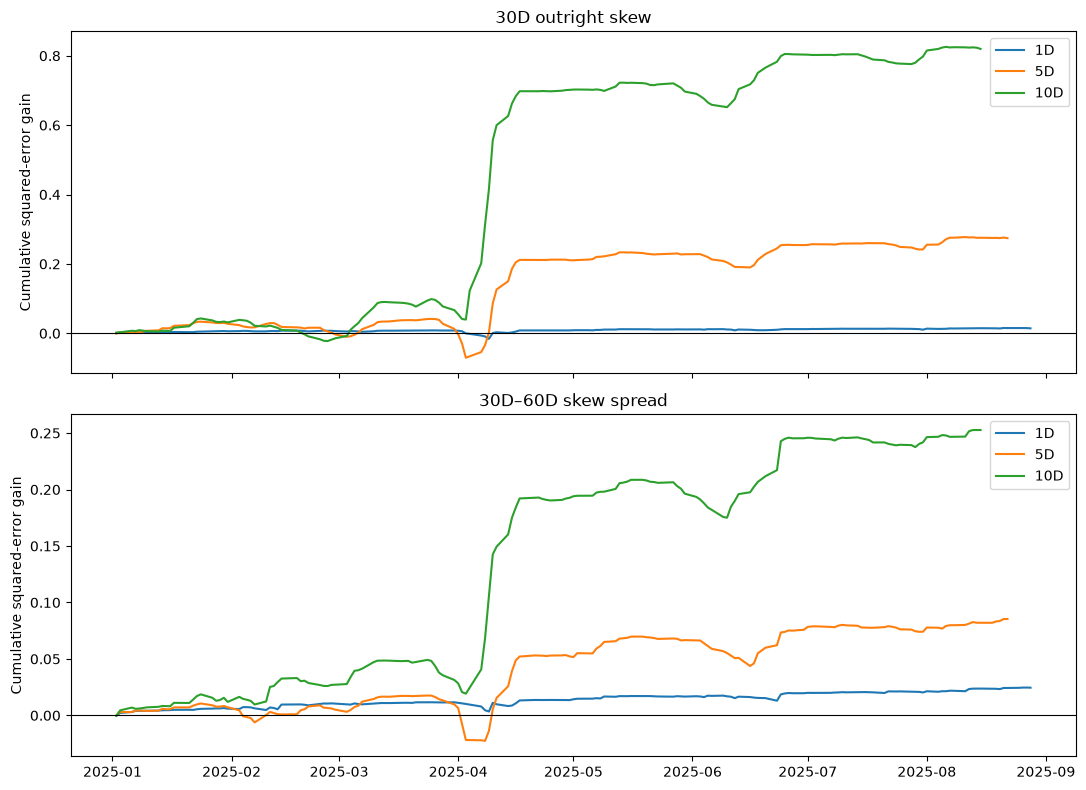

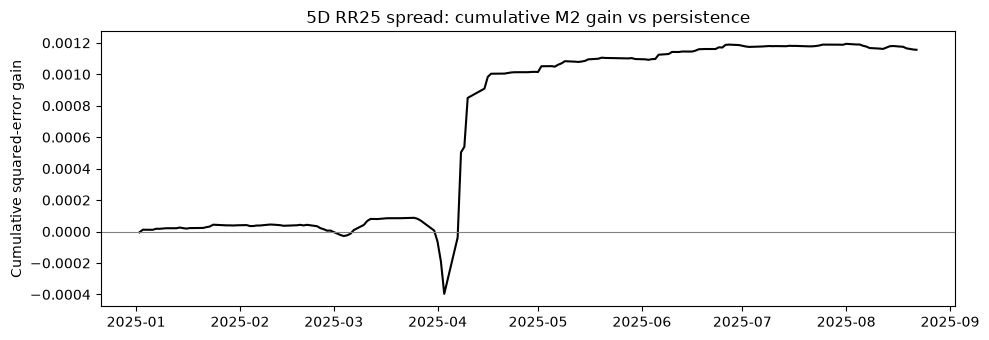

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for ax, state, label in zip(axes, ['skew_30', 'skew_30_60'], ['30D outright skew', '30D–60D skew spread']):
    for h in (1, 5, 10):
        gains = cumulative_m2_gain(common_rows[state, h])
        ax.plot(gains.quote_date, gains.gain, label=f'{h}D')
    ax.axhline(0, color='black', linewidth=.8)
    ax.set_title(label)
    ax.set_ylabel('Cumulative squared-error gain')
    ax.legend()
fig.tight_layout()
plt.show()
rr_gains = cumulative_m2_gain(common_rows['rr25_30_60', 5])
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(rr_gains.quote_date, rr_gains.gain, color='black')
ax.axhline(0, color='grey', linewidth=.8)
ax.set_title('5D RR25 spread: cumulative M2 gain vs persistence')
ax.set_ylabel('Cumulative squared-error gain')
fig.tight_layout()
plt.show()

## Interpretation

All fitted M2 slopes are negative at 1D, 5D and 10D for both skew states. M2 beats persistence at all three horizons; 5D sits between the smaller 1D and larger 10D relative gains, although horizons have different targets and samples. The 5D RR25-spread alternative also favours M2 (OOS R² 0.225). Both headline 5D targets improve on persistence in all five fixed non-overlapping offsets. The development-fixed extreme-move threshold removes 5 outright and 1 spread confirmation observations; OOS R² remains positive (0.255 and 0.204). Separately, the confirmation top-1%-removed diagnostic removes exactly 2 of 158 realised observations per target; M2 still beats persistence (RMSE 0.087088 vs 0.094375 outright and 0.046976 vs 0.051507 spread; OOS R² 0.148 and 0.168). The latter trim uses 2025 outcomes and is explicitly post-confirmation, not an untouched test.

The VIX split qualifies the result: gains are near zero for VIX < 20 (R² 0.005 outright, 0.023 spread) and much larger for VIX ≥ 20 (0.254 and 0.296); neither regime has fewer than 30 scored observations. This is descriptive, not evidence for regime-specific refitting. The fixed-lag-4 HAC 95% intervals for mean squared-error gain include zero for both targets (outright [-0.001109, 0.004580]; spread [-0.000356, 0.001437]). With 158 overlapping scored origins, these checks do **not** establish a precise positive mean loss gain. Overall, the sign/horizon/RR25/offset/outlier checks support the confirmed M2-versus-persistence finding, but its regime dependence and wide HAC intervals materially limit the strength of a broad statistical claim. The frozen headline result and failed M6 confirmation remain unchanged.